# Basic Statistics

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [29]:
df=pd.read_csv('sales_data_with_discounts.csv')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [31]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [32]:
### number of numerical columns are 6
num_col=df.select_dtypes(include=['number']).columns.tolist()
num_col

['Volume',
 'Avg Price',
 'Total Sales Value',
 'Discount Rate (%)',
 'Discount Amount',
 'Net Sales Value']

In [33]:
stats_dict = {
    'Mean': df[num_col].mean(),
    'Median': df[num_col].median(),
    'Mode': df[num_col].mode().iloc[0],
    'Standard Deviation': df[num_col].std()
}

In [34]:
statsdf=pd.DataFrame(stats_dict)
statsdf

,Mean,Median,Mode,Standard Deviation
Volume,5.066667,4.000000,3.000000,4.231602
Avg Price,10453.433333,1450.000000,400.000000,18079.904840
Total Sales Value,33812.835556,5700.000000,24300.000000,50535.074173
Discount Rate (%),15.155242,16.577766,5.007822,4.220602
Discount Amount,3346.499424,988.933733,69.177942,4509.902963
Net Sales Value,30466.336131,4677.788059,326.974801,46358.656624


## Brief interpretation of these statistics.
1. **Orders are small:** Most purchases consist of only 3 0r 4 items. Large bulk orders rarely occur.
2. **Volume is steady:** The low standard deviation for volume shows that the number of items bought per transaction stays consistent and close to the average.
3. **Averages are misleading:** the average price looks high due to a massive sales.In reality, most items cost between 400 to 1450.
4. **Revenue is unpredictable:** Sales numbers fluctuate heavily. Total money coming in goes up and down sharply from one order to the other order.
5. **Discount rates are stable:** Customers regularly receive a price reduction of 15% to 16%. This percentage stays consistent.
6. **Net sales are uneven:** The final money kept after discounts is highly variable. Most orders bring in around $4,677, but rare sales bring in tens of thousands.

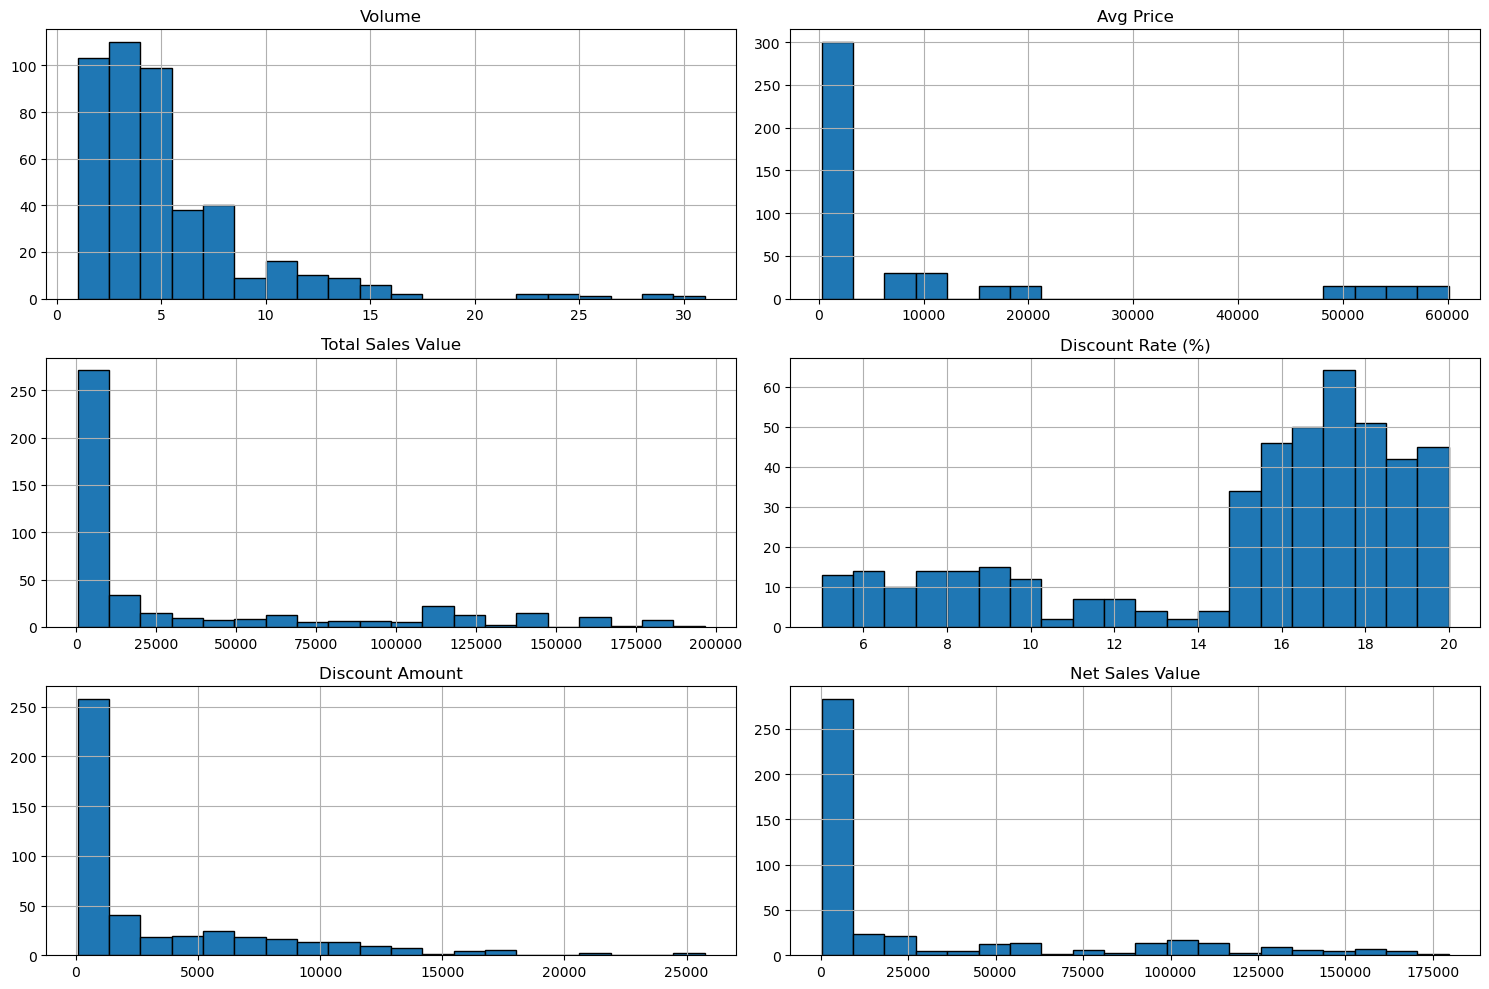

In [39]:
## Histogram
df.hist(column=num_col, figsize=(15, 10), bins=20, grid=True, edgecolor='black')
plt.tight_layout()
plt.show()

### Distribution Analysis and Inferences:
* **Volume distribution is right-skewed:** The graph peaks heavily between 2 and 5 items per order. A thin, long tail stretches out to 30 items due to rare bulk orders.
* **Avg Price has extreme right skewness:** Over 300 items are tightly clustered at the ultra-low end near 400. A few expensive premium products create isolated groups all the way out at 50,000 to 60,000.
* **Total Sales Value drops off instantly:** More than 250 transactions generate low gross amounts under 10,000. The rest of the data forms a very long, flat floor extending all the way up to 200,000.
* **Discount Rate has two distinct zones:** The chart shows a small, flat group of orders getting baseline discounts between 5% and 10%. It then spikes into a massive peak clustered heavily between 15% and 20%.
* **Discount Amount is heavily bottom-heavy:** The vast majority of orders take a very small bite out of revenue under 1,500. A tiny fraction of large sales stretch the right tail out past 25,000 in given-away cash.
* **Net Sales Value matches gross value:** The final revenue pattern looks identical to the total sales chart. Most orders bring in very little final money, while rare spikes climb toward 175,000.

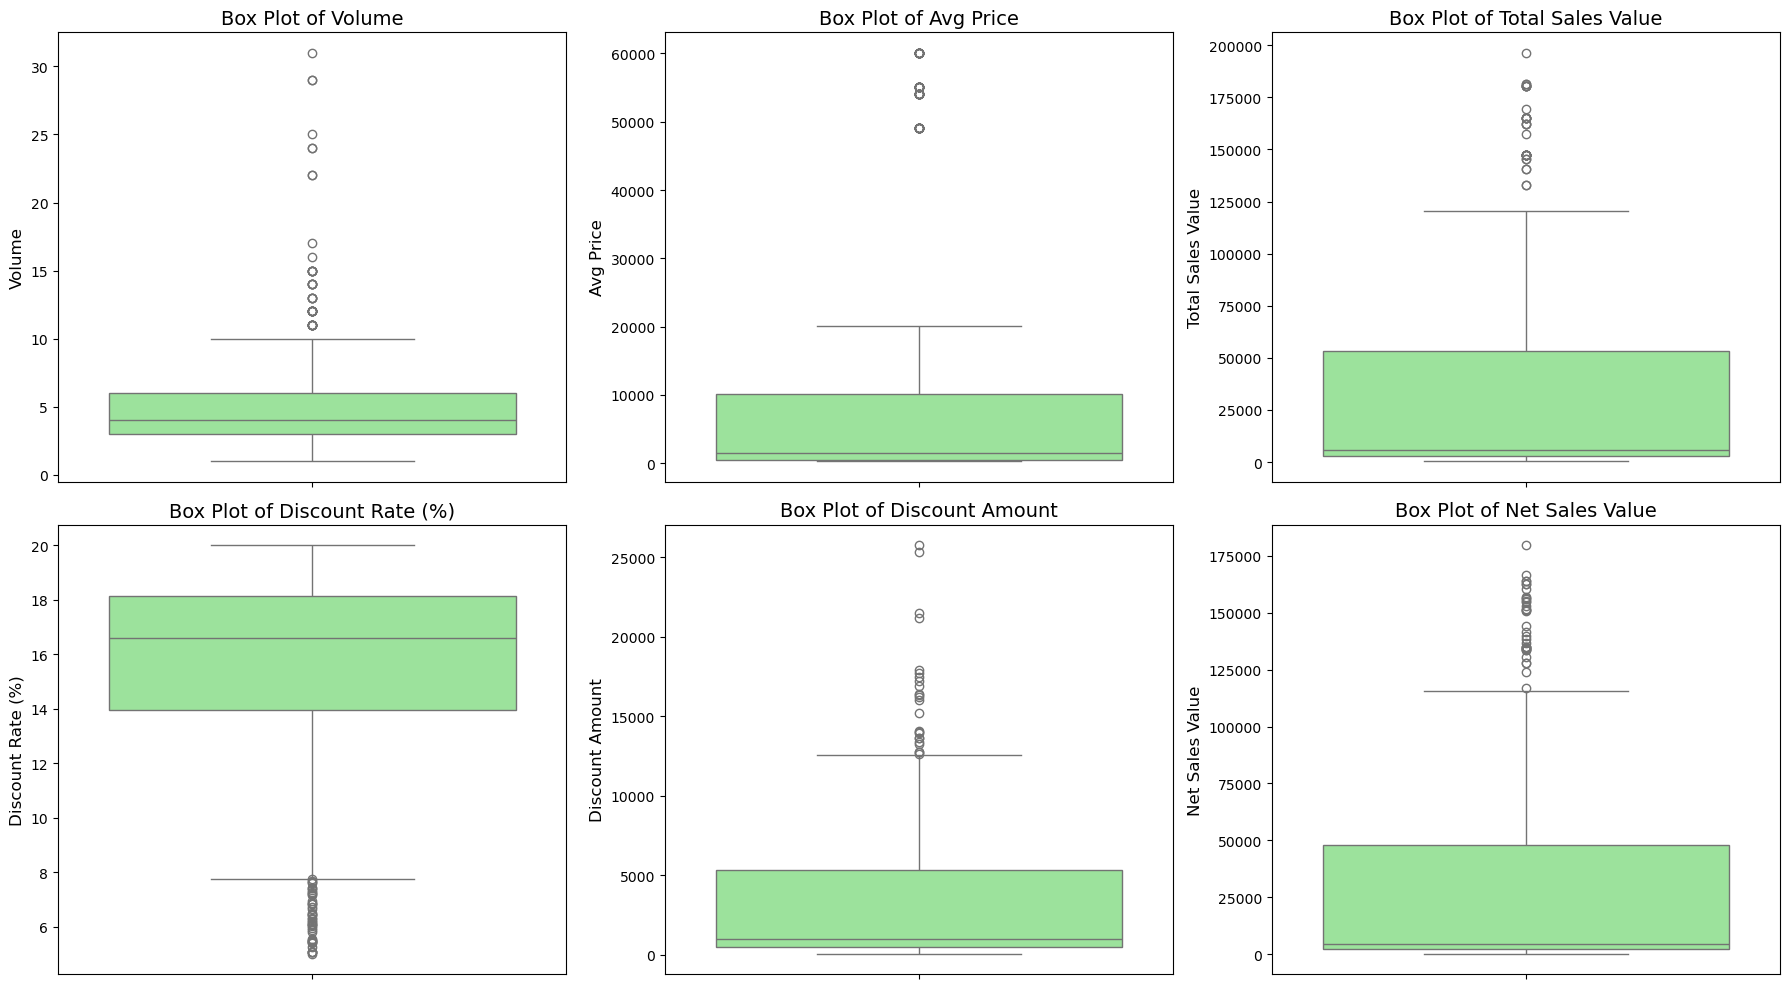

In [40]:
# Box Plot
plt.figure(figsize=(18, 10))
for i, col in enumerate(num_col, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Box Plot of {col}', fontsize=14)
    plt.ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()

### Identification of Extreme Values and Unusual Distributions
* **Most orders are small, but a few are huge:** The green box represents the IQR (the middle 50% of the data), which ranges from 3 to 6 items. The dots climbing up the chart show that a few unusual bulk orders hit all the way up to 31 items.
* **Most items are cheap, but a few cost a fortune:** The IQR box sits flat at the bottom, ranging from roughly 400 to 10,000, because most items in the inventory are low-priced. The three lonely dots floating near 50,000 and 60,000 show that there is a tiny handful of extremely expensive luxury products.
* **Total sales are usually low, with rare massive spikes:** Normal order values sit inside the IQR box on the lower end between 0 and 54,000. However, a long, crowded line of dots runs all the way up to 200,000, proving that big-money orders happen pretty regularly.
* **Discounts are steady, with a few unusually low drops:** The discount percentage stays stable inside the IQR box between 14% and 18% for most transactions. Unlike everything else, there are no high spikes here; instead, a few rare orders got unusually low discounts down near 6%.
* **Cash give-backs are small, except on big orders:** The actual dollar amount given away as a discount stays very low inside the IQR box, ranging from 0 to 5,000 for regular purchases. But because of those rare expensive items, a few orders gave away massive price cuts over 25,000.
* **Final take-home revenue matches sales trends:** The final money kept after giving discounts looks exactly like the total sales graph, with the IQR box compressed at the bottom between 0 and 48,000. Most transactions bring in small revenue, but a handful of jackpot sales from VIP buyers bring in giant payouts close to 175,000.

In [24]:
### Bar Chart
cat_cols = df.drop(columns=num_col).columns
cat_cols

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

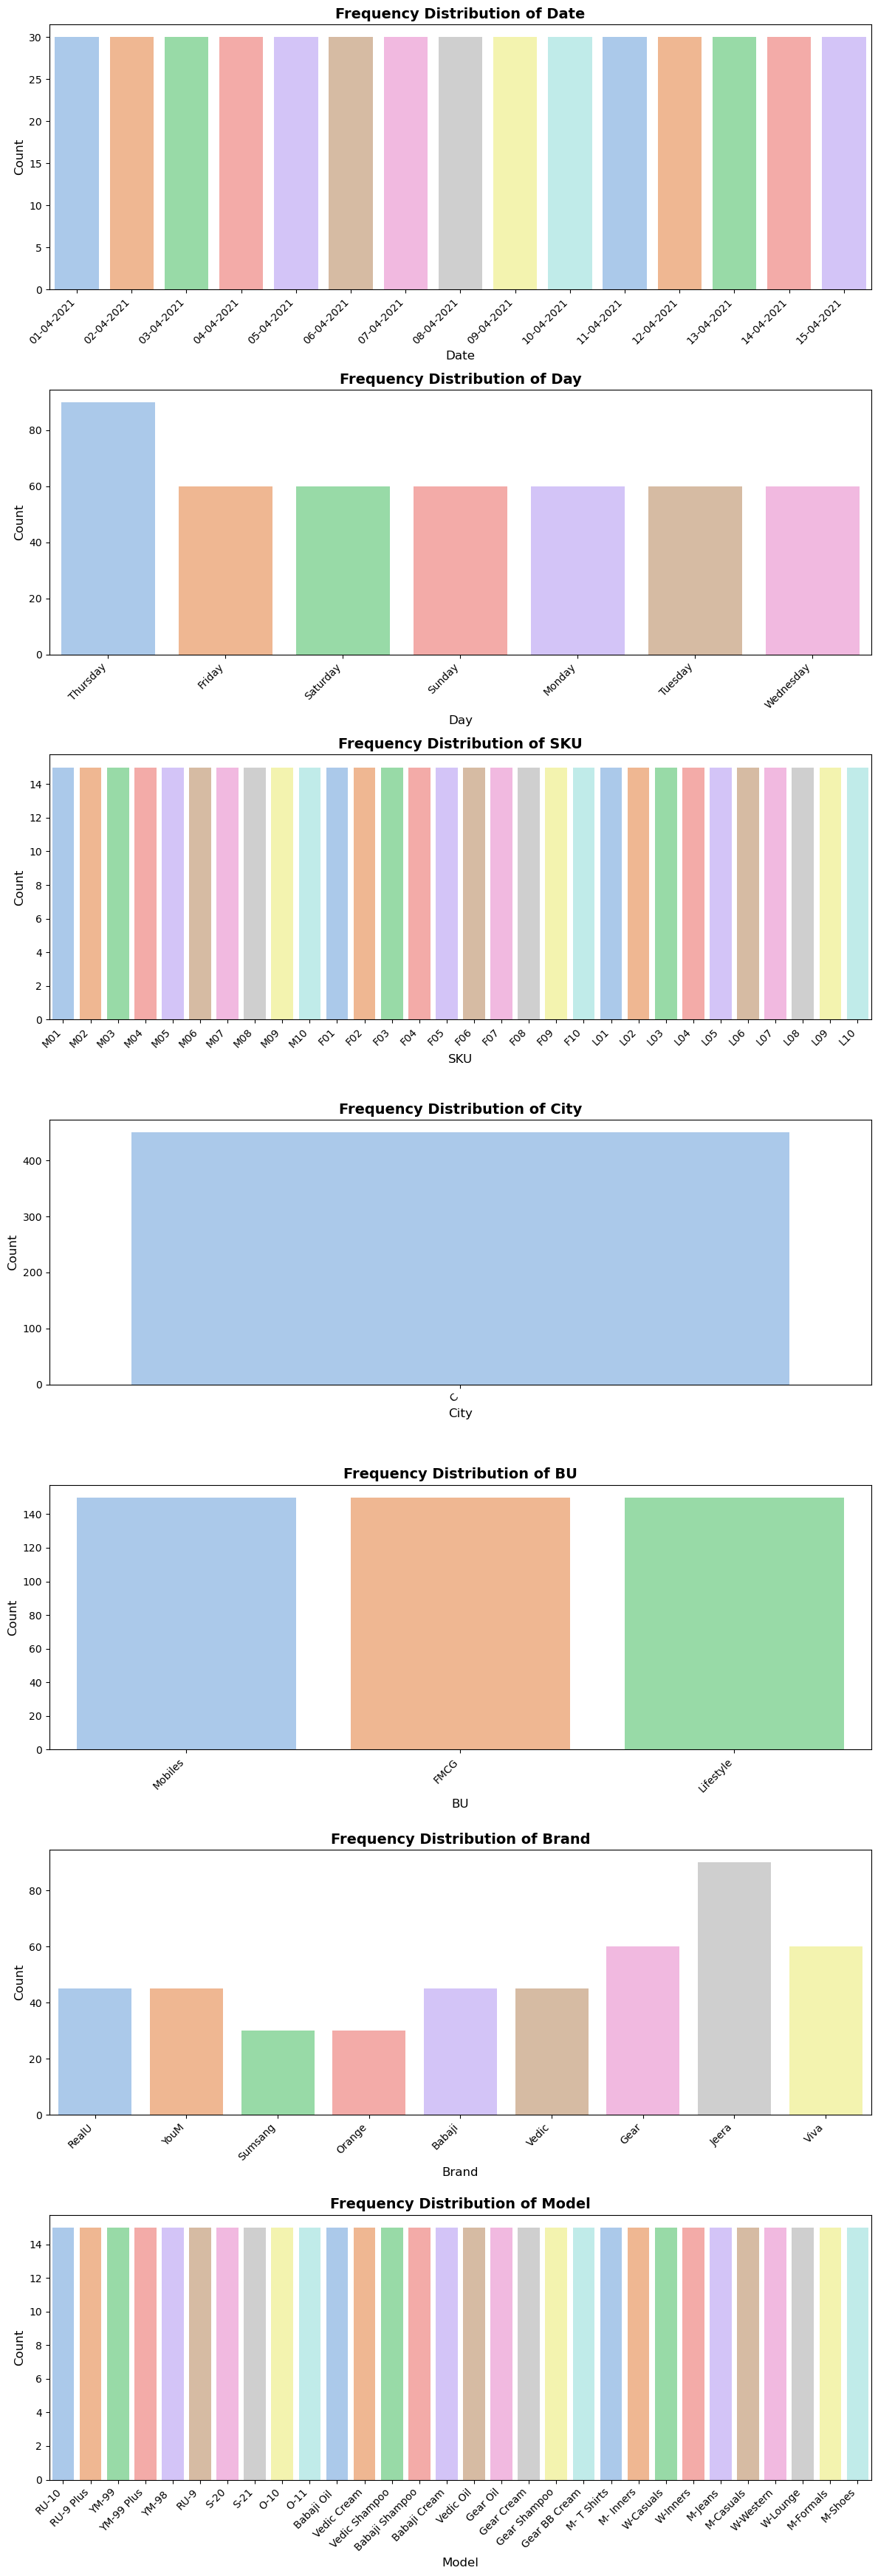

In [38]:
plt.figure(figsize=(12, 35))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(7, 1, i)
    sns.countplot(x=col, data=df, palette='pastel')
    plt.title(f'Frequency Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Insights
* **Date counts are perfectly uniform:** Every single date has exactly 30 transactions recorded, showing a completely flat and perfectly balanced distribution over time.
* **Thursday shows an unexpected spike:** Thursday has a higher transaction count of 90, while every other day of the week stays perfectly tied at exactly 60 transactions.
* **SKU and Model counts are completely identical:** Every unique stock code (SKU) and every unique product build (Model) has exactly 15 entries, showing no variance in sales frequency among individual items.
* **City data contains only one location:** The entire dataset of 450 transactions is recorded under a single city, meaning there is zero geographic variety in this data.
* **Business Units are perfectly balanced:** The three product departments (Phones, FMCG, and Lifestyle) have exactly 150 transactions each, dividing the dataset into three perfectly equal parts.
* **Brand popularity shows the only real variation:** Real distribution differences appear only across brands. One specific brand dominates consumer choice with a peak near 90 sales, while another brand drops to a low of 30.

### Extreme Values and Unusual Distributions
 * **Unusual artificial uniformity:** The chart distributions for Date, SKU, Business Unit (BU), and Model are completely flat and equal. This pattern is highly unusual for real-world retail activity and shows that the data was perfectly balanced or simulated.
 * **Extreme geographic concentration:** The City chart shows an absolute concentration of 100% of the transactions occurring in just a single city. This reveals a total lack of regional or geographic variety in the dataset.
 * **Isolated single-day spike:** The day-of-the-week distribution reveals an unusual spike on Thursdays, which records 90 transactions. Every other day of the week remains perfectly locked at exactly 60 transactions.

### Summary of Key Findings
* **Most orders are small and steady:** Customers usually buy just 3 or 4 items at a time, meaning regular daily package sizes stay very predictable.
* **High prices pull up the statistical averages:** Normal prices look much higher than they really are because a few extremely expensive premium products warp the calculation. 
* **Big profits come from rare sales:** Regular daily sales bring in small money, so total business revenue relies on rare, massive orders that spike up to 175,000.
* **Discounts stay locked in a tight range:** Price cuts are strictly controlled and almost always stick between 14% and 18% throughout the year.
* **Cash give-backs explode on luxury items:** Even though the discount percentage is steady, the actual dollar amount given away grows massive on high-priced products, sometimes topping 25,000.
* **The charts show an artificial flat pattern:** Sales counts are perfectly equal across all dates, departments, stock codes, and models, which proves the data was artificially created or cleaned.
* **Sales lack geographic and daily variety:** Every single transaction happens in the exact same city, while weekly tracking stays completely flat except for a small jump on Thursdays.